### EXP: Face Detection using Haar Cascades with OpenCV and Matplotlib
### Name: ARAVINDAN SD
### Reg no: 212224243001

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [18]:
# Step 1: Read the image and convert the image into RGB
image = cv2.imread('cc.jpg')  # Replace with your image path
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

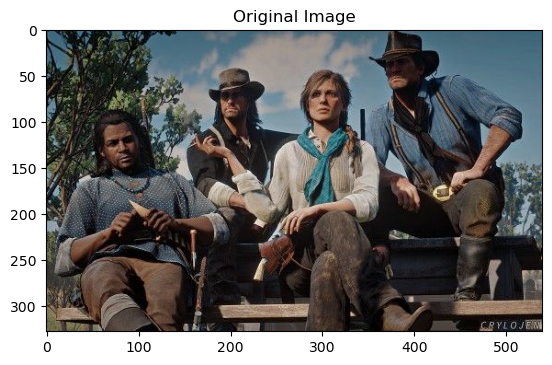

In [19]:
# Step 2: Display the original image
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('on')
plt.show()

In [20]:
# Step 4: Set the pixels to display the ROI (Region of Interest)
# Define the coordinates for the Region of Interest (ROI)
# (startY:endY, startX:endX)
roi = image[100:420, 200:550]  # ROI coordinates (adjust as needed)

# Create a blank mask of the same size as the original image
mask = np.zeros_like(image)

# Place the ROI on the mask
mask[100:420, 200:550] = roi

In [21]:
# Step 5: Perform bitwise conjunction of the two arrays using bitwise_and
segmented_roi = cv2.bitwise_and(image, mask)

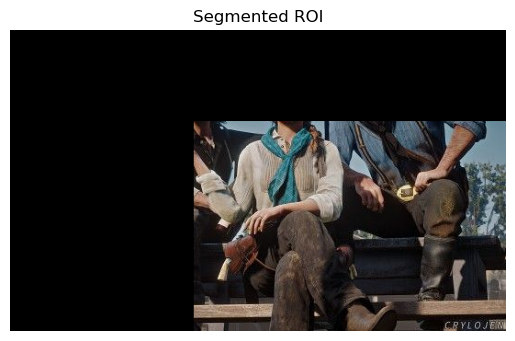

In [22]:
# Step 6: Display the segmented ROI from the image
segmented_roi_rgb = cv2.cvtColor(segmented_roi, cv2.COLOR_BGR2RGB)
plt.imshow(segmented_roi_rgb)
plt.title("Segmented ROI")
plt.axis('off')
plt.show()


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [24]:
# Step 1: Read the image and convert it to RGB for displaying
image = cv2.imread('wh.jpg')  # Replace with your actual image file path
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

(np.float64(-0.5), np.float64(438.5), np.float64(290.5), np.float64(-0.5))

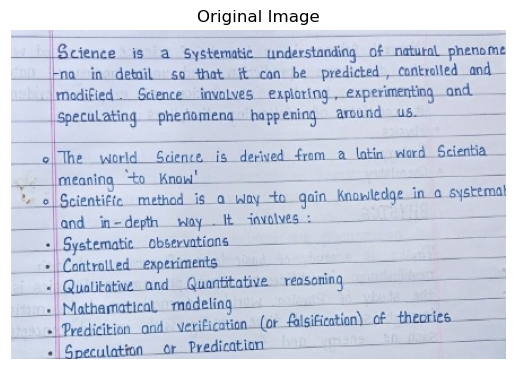

In [25]:
# Original Image
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')

In [26]:
# Step 2: Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale


In [27]:
# Step 3: Apply Gaussian blur to reduce noise
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)  # Apply Gaussian blur (5x5 kernel)

In [28]:
# Step 5: Use Canny edge detector to find edges
edges = cv2.Canny(blurred_image, 50, 150)  # Detect edges using Canny (thresholds 50 and 150)

(np.float64(-0.5), np.float64(438.5), np.float64(290.5), np.float64(-0.5))

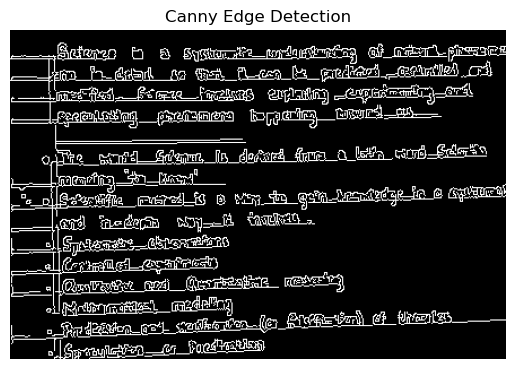

In [29]:
# Canny Edge Detection
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')

In [30]:
# Step 6: Find contours in the edged image
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [31]:
# Step 7: Filter contours based on area and draw bounding boxes
result_image = image.copy()  # Create a copy of the original image to draw bounding boxes
for contour in contours:
    if cv2.contourArea(contour) > 50:  # Filter out small areas
        x, y, w, h = cv2.boundingRect(contour)  # Get the bounding box for the contour
        cv2.rectangle(result_image, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Draw the rectangle

(np.float64(-0.5), np.float64(438.5), np.float64(290.5), np.float64(-0.5))

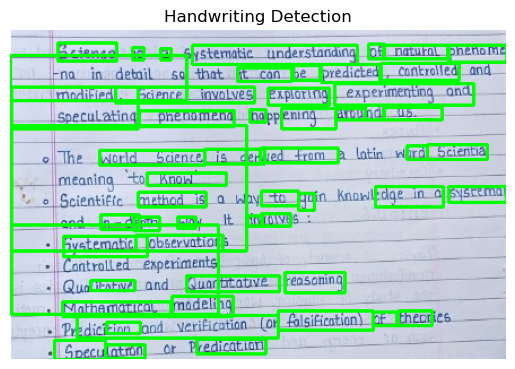

In [32]:
# Handwriting Detection Result
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.title("Handwriting Detection")
plt.axis('off')

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [34]:
config_file = 'deploy.prototxt'  # Path to the config file
weights = 'mobilenet_iter_73000.caffemodel'  # Path to the weights file

In [35]:
print("OpenCV version:", cv2.__version__)
print("DNN module available:", hasattr(cv2, "dnn"))
print("readNet available:", hasattr(cv2.dnn, "readNet"))

OpenCV version: 4.10.0
DNN module available: True
readNet available: True


In [36]:
config_file = "deploy.prototxt"
weights = "mobilenet_iter_73000.caffemodel"

print("Config file:", config_file)
print("Weights file:", weights)

Config file: deploy.prototxt
Weights file: mobilenet_iter_73000.caffemodel


In [37]:
%pip install opencv-python==4.10.0.84

Note: you may need to restart the kernel to use updated packages.


In [38]:
net = cv2.dnn.readNet(weights, config_file)

print("MobileNet-SSD model loaded successfully!")

MobileNet-SSD model loaded successfully!


In [39]:
class_labels = {
    0: "background",
    1: "aeroplane",
    2: "bicycle",
    3: "bird",
    4: "boat",
    5: "bottle",
    6: "bus",
    7: "car",
    8: "cat",
    9: "chair",
    10: "cow",
    11: "diningtable",
    12: "dog",
    13: "horse",
    14: "motorbike",
    15: "person",
    16: "pottedplant",
    17: "sheep",
    18: "sofa",
    19: "train",
    20: "tvmonitor"
}

print("Class labels created")

Class labels created


In [40]:
image = cv2.imread("bike.jpg")

if image is None:
    print("ERROR: bike.jpg not found")
else:
    print("Image loaded successfully")
    print("Image size:", image.shape)

Image loaded successfully
Image size: (1308, 736, 3)


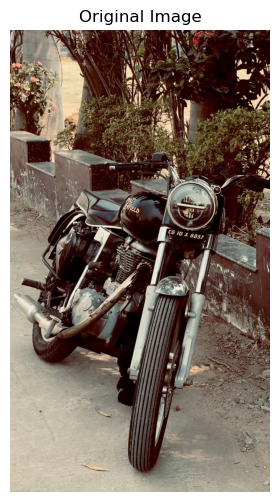

In [41]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [42]:
blob = cv2.dnn.blobFromImage(
    image,
    scalefactor=0.007843,
    size=(300, 300),
    mean=127.5
)

print("Blob created successfully")
print("Blob shape:", blob.shape)

Blob created successfully
Blob shape: (1, 3, 300, 300)


In [43]:
net.setInput(blob)

detections = net.forward()

print("Detection completed successfully")
print("Detection shape:", detections.shape)

Detection completed successfully
Detection shape: (1, 1, 100, 7)


In [44]:
confidence_threshold = 0.5

for i in range(detections.shape[2]):

    confidence = detections[0, 0, i, 2]

    if confidence > confidence_threshold:

        index = int(detections[0, 0, i, 1])

        label = class_labels.get(index, "Unknown")

        print(
            label,
            "Confidence:",
            round(confidence * 100, 2),
            "%"
        )

motorbike Confidence: 93.08 %
motorbike Confidence: 81.85 %


In [45]:
(h, w) = image.shape[:2]

for i in range(detections.shape[2]):

    confidence = detections[0, 0, i, 2]

    if confidence > 0.5:

        index = int(detections[0, 0, i, 1])
        label = class_labels.get(index, "Unknown")

        box = detections[0, 0, i, 3:7] * np.array(
            [w, h, w, h]
        )

        startX, startY, endX, endY = box.astype("int")

        startX = max(0, startX)
        startY = max(0, startY)
        endX = min(w - 1, endX)
        endY = min(h - 1, endY)

        # Large label text
        text = "{}: {:.1f}%".format(
            label,
            confidence * 100
        )

        # Draw thick bounding box
        cv2.rectangle(
            image,
            (startX, startY),
            (endX, endY),
            (0, 255, 0),
            3
        )

        # Font settings
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1.2
        thickness = 3

        # Get text size
        (text_width, text_height), baseline = cv2.getTextSize(
            text,
            font,
            font_scale,
            thickness
        )

        # Draw filled background behind text
        cv2.rectangle(
            image,
            (startX, max(0, startY - text_height - baseline - 10)),
            (startX + text_width + 10, startY),
            (0, 255, 0),
            -1
        )

        # Draw large label
        cv2.putText(
            image,
            text,
            (startX + 5, startY - 5),
            font,
            font_scale,
            (0, 0, 0),
            thickness,
            cv2.LINE_AA
        )

print("Large labels and bounding boxes drawn successfully")

Large labels and bounding boxes drawn successfully


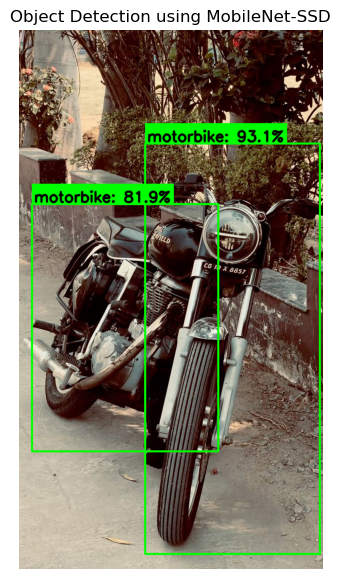

In [46]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 7))
plt.imshow(image_rgb)
plt.title("Object Detection using MobileNet-SSD")
plt.axis("off")
plt.show()